# Modeling Variance Threshold - Decision Tree - Hugo Fiévet

## Table of Contents

1. [Objective](#1-objective)
2. [Baseline Model](#2-baseline-model)
3. [Hyperparameter Tuning](#3-hyperparameter-tuning)
4. [Final Evaluation](#4-final-evaluation)
5. [Model Limits](#5-model-limits)

## 1. Objective

Établir une performance de référence du modèle avec ses paramètres par défaut avant optimisation des hyperparamètres.

## 2. Baseline Model

In [7]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, cross_validate,GridSearchCV,StratifiedKFold
from sklearn.metrics import  accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix

RANDOM_STATE = 42

dt =  DecisionTreeClassifier(random_state=RANDOM_STATE)

xtrain_VT = pd.read_csv("xtrain_VT.csv")
ytrain = pd.read_csv("ytrain.csv").squeeze("columns")

StratifiedKfold_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

cv_results = cross_validate(estimator=dt,X=xtrain_VT,y=ytrain,scoring="f1_macro",return_train_score=True,cv=StratifiedKfold_cv)
pd.DataFrame(cv_results)

,fit_time,score_time,test_score,train_score
0,0.303900,0.008956,0.668378,1.0
1,0.307392,0.008891,0.655129,1.0
2,0.296672,0.008832,0.656398,1.0
3,0.289553,0.008743,0.669236,1.0
4,0.334178,0.008840,0.651780,1.0


In [8]:
print("Mean train score : ",cv_results["train_score"].mean())
print("Mean validation score",cv_results["test_score"].mean())

Mean train score :  1.0
Mean validation score 0.6601843790709612


Le Decision Tree avec ses paramètres par défaut obtient un F1-macro moyen d’environ **0,660** en validation croisée.

Le F1-macro moyen d’entraînement atteint **1,000**, soit un écart d’environ **0,340** avec la validation. Cet écart important met en évidence un surapprentissage marqué.

Cette baseline montre que l’arbre est trop complexe dans sa configuration par défaut. L’optimisation doit donc limiter sa complexité afin d’améliorer sa capacité de généralisation.

## 3. Hyperparameter Tuning

In [9]:
settings_grid = {
    "max_depth":[None,10,20],
    "min_samples_leaf":[1, 2, 5],
    "max_features":["sqrt", 0.5],
}

grid_search =  GridSearchCV(estimator=dt,param_grid=settings_grid,scoring="f1_macro",cv=StratifiedKfold_cv,return_train_score=True)

grid_search.fit(
    xtrain_VT,
    ytrain,
)


,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'max_depth': [None, 10, ...], 'max_features': ['sqrt', 0.5], 'min_samples_leaf': [1, 2, ...]}"
,scoring,'f1_macro'
,n_jobs,None
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,criterion,'gini'


In [10]:
best_index = grid_search.best_index_

print("Best parameters:", grid_search.best_params_)

print("Best validation F1:", grid_search.best_score_)
print(
    "Mean train F1:",
    grid_search.cv_results_["mean_train_score"][best_index]
)
print(
    "Std validation F1:",
    grid_search.cv_results_["std_test_score"][best_index]
)

Best parameters: {'max_depth': 10, 'max_features': 0.5, 'min_samples_leaf': 5}
Best validation F1: 0.6971305958787755
Mean train F1: 0.8169436197738594
Std validation F1: 0.011446398302219081


L’optimisation du Decision Tree sélectionne `max_depth=10`, `max_features=0.5` et `min_samples_leaf=5`.

Le F1-macro moyen de validation atteint **0,697**, contre environ **0,660** pour la baseline. En parallèle, le F1-macro moyen d’entraînement diminue de **1,000 à 0,817**.

L’écart entraînement–validation est ainsi réduit d’environ **0,340 à 0,120**. La régularisation diminue nettement le surapprentissage tout en améliorant le score de validation.

L’écart-type du F1-macro de validation est d’environ **0,011**, ce qui montre une variabilité modérée entre les folds.

## 4. Final Evaluation

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
X_test_VT = pd.read_csv("xtest_VT.csv")
y_test = pd.read_csv("ytest.csv").squeeze("columns")

best_model = grid_search.best_estimator_

y_pred = best_model.predict(X=X_test_VT)

class_report = classification_report(y_test, y_pred)
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="macro")
recall = recall_score(y_test, y_pred, average="macro")
f1 = f1_score(y_test, y_pred, average="macro")

print("Accuracy :",accuracy )
print("Precision macro :",precision )
print("Recall macro :",recall )
print("F1 macro :", f1)

Accuracy : 0.7323869610935857
Precision macro : 0.6996367643709807
Recall macro : 0.7111165377007773
F1 macro : 0.704300448270943


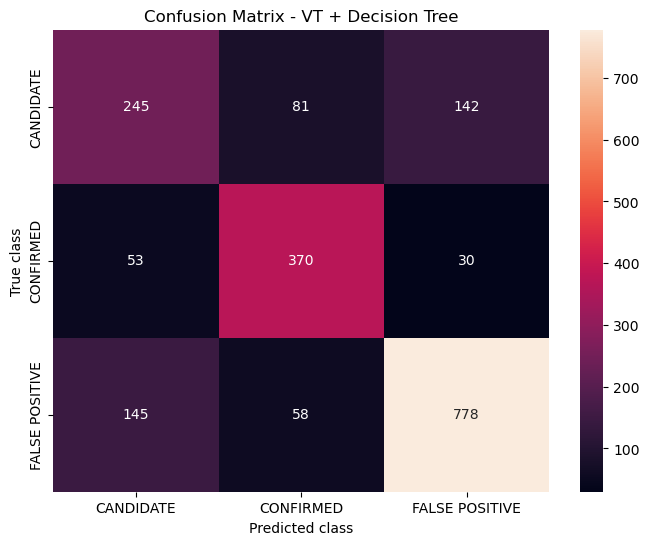

In [12]:
labels = ["CANDIDATE", "CONFIRMED", "FALSE POSITIVE"]

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=labels
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels,
)

plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.title("Confusion Matrix - VT + Decision Tree")

plt.show()

Le Decision Tree utilisant la sélection Variance Threshold présente également de bonnes performances pour les classes `CONFIRMED` et FALSE POSITIVE, mais éprouve davantage de difficultés avec la classe CANDIDATE.

Parmi les 468 CANDIDATE, seuls 245 sont correctement identifiés, tandis que 81 sont prédits CONFIRMED et 142 sont prédits FALSE POSITIVE. Sur les 453 CONFIRMED, 370 sont correctement classés, et sur les 981 FALSE POSITIVE, 778 sont correctement reconnus.

La principale faiblesse du modèle concerne donc la reconnaissance des candidats, avec une tendance relativement importante à les classer comme faux positifs.

## 5. Model Limits

Le Decision Tree avec Variance Threshold reste moins performant que le Random Forest, malgré l’utilisation d’un plus grand ensemble de variables. Cela montre qu’un nombre plus important de features ne garantit pas une meilleure classification. Le problème semble ici davantage lié à la capacité de généralisation d’un arbre unique qu’à la sélection des variables elle-même. Cette combinaison illustre donc l’intérêt de distinguer l’effet de la sélection de variables de celui de l’algorithme choisi.